<a href="https://colab.research.google.com/github/sadbinsiddique/Dl-net/blob/main/notebook/3.%20Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Training with **Colab**

<div style="display: flex; flex-direction: column; align-items: center; justify-content: center; padding: 20px;">
    <div style="display: flex; gap: 12px; align-items: center; justify-content: center; flex-wrap: wrap;">
        <a href="https://colab.research.google.com/github/sadbinsiddique/Dl-net/blob/main/notebook/3.%20Train.ipynb" target="_blank" style="display: inline-flex; align-items: center; justify-content: center; gap: 6px; padding: 8px 16px; background: rgba(255, 255, 255, 0.15); backdrop-filter: blur(12px); -webkit-backdrop-filter: blur(12px); color: white; border-radius: 12px; text-decoration: none; font-weight: 600; font-size: 13px; border: 1px solid rgba(255, 255, 255, 0.25); cursor: pointer; transition: all 0.3s ease;">
            <img src="https://github.com/sadbinsiddique/Dl-net/blob/main/public/google-colab.svg?raw=1" alt="Online" style="width: 20px; height: 20px;">
            Google Colab
        </a>
        <a href="https://github.com/settings/tokens" target="_blank" style="display: inline-flex; align-items: center; justify-content: center; gap: 6px; padding: 8px 16px; background: rgba(255, 255, 255, 0.15); backdrop-filter: blur(12px); -webkit-backdrop-filter: blur(12px); color: white; border-radius: 12px; text-decoration: none; font-weight: 600; font-size: 13px; border: 1px solid rgba(255, 255, 255, 0.25); cursor: pointer; transition: all 0.3s ease;">
            <img src="https://github.com/sadbinsiddique/Dl-net/blob/main/public/github.png?raw=1" alt="Active" style="width: 20px; height: 20px;">
            Access Token
        </a>
    </div>
</div>

In [1]:
from getpass import getpass
import os

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Cloud-Base Environment: {IN_COLAB}")

if IN_COLAB:
    env="colab"
    token = getpass('Enter GitHub Access Token: ')
    !git clone https://{token}@github.com/sadbinsiddique/Dl-net.git
    os.chdir('/content/Dl-net')
else:
    env="local"
    print("Local environment detected. \nSkipping git clone.")

Cloud-Base Environment: True
Enter GitHub Access Token: ··········
Cloning into 'Dl-net'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 192 (delta 101), reused 147 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (192/192), 2.29 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (101/101), done.


++++++++++++++++++++++++++++++++++++++++++++++++++
Step 01: [data init]
++++++++++++++++++++++++++++++++++++++++++++++++++


[1]Dataset: data/casme2-preprocessed-v2


[2]Dataset: data/ckplusferdata


[3]Dataset: data/sammassamexpression
++++++++++++++++++++++++++++++++++++++++++++++++++
Step 02: [EDA]
++++++++++++++++++++++++++++++++++++++++++++++++++
[1]Starting EDA : ./data/ckplusferdata
[2]Found 35887 total files.


> Extracting Metadata: 100%|██████████| 35887/35887 [00:07<00:00, 4547.44it/s]


[4]Valid images: 35887 | Corrupted: 0


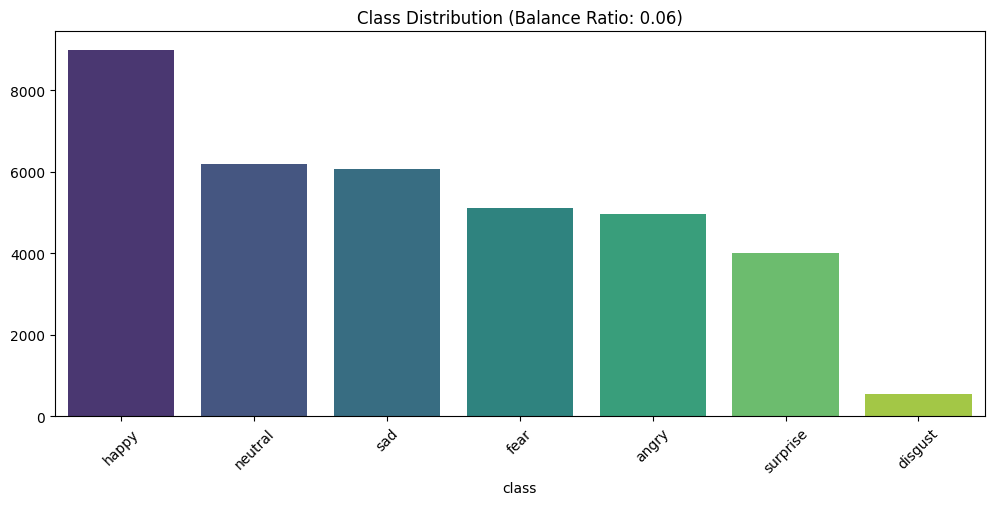

[5]Calculating image metrics...


KeyboardInterrupt: 

In [8]:
!pip install imagehash

import importlib
from src.utils import pipeline
importlib.reload(pipeline)
from src.utils.pipeline import _run_pipeline
_run_pipeline()

In [ ]:
if IN_COLAB:
    os.chdir('/content/Dl-net')
    DATA_PATH = '/content/Dl-net/notebook/'
    print(f"Colab environment setup. Current working directory: {os.getcwd()}")
else:
    DATA_PATH = './'
    print(f"Local environment. Data path: {DATA_PATH}")

print(f"Data will be loaded from: {DATA_PATH}")

Colab environment setup. Current working directory: /content/Dl-net
Data will be loaded from: /content/Dl-net/notebook/


In [ ]:
from content.Dl-net.src.utils.pipeline import _run_pipeline  # pyright: ignore[reportMissingImports]

_run_pipeline() # pyright: ignore[reportMissingImports]

### Main Cord Start

In [ ]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd


In [ ]:
train_df = pd.read_csv(f"{DATA_PATH}train.csv")
test_df = pd.read_csv(f"{DATA_PATH}test.csv")

test = test_df[["filepath","class"]]
train = train_df[["filepath","class"]]

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

In [ ]:
test['class'].unique()

<ArrowStringArray>
['neutral', 'angry', 'sad', 'happy', 'fear']
Length: 5, dtype: str

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class EmotionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image = Image.open(
            self.df.loc[idx,"filepath"]
        ).convert("RGB")

        label = int(self.df.loc[idx,"label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torch.utils.data import DataLoader

train_dataset = EmotionDataset(train, train_transform)
val_dataset = EmotionDataset(test, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

## Alex Net


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

num_classes = 5

model.classifier[6] = nn.Linear(
    4096,
    num_classes
)

model = model.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
from tqdm import tqdm

epochs = 20

for epoch in range(epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    print(
        f"Epoch {epoch+1} | "
        f"Loss={train_loss/len(train_loader):.4f} | "
        f"Accuracy={100*correct/total:.2f}%"
    )

  0%|          | 0/590 [00:00<?, ?it/s]